0
              YEAR          DOY          T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean   2020.131451   180.121227    26.656928    28.914667    24.886461   
min    2015.000000     1.000000    21.120000    25.260000    15.170000   
25%    2017.000000    86.000000    25.720000    27.920000    24.100000   
50%    2020.000000   179.000000    26.820000    28.990000    25.100000   
75%    2023.000000   272.000000    27.540000    29.910000    25.860000   
max    2026.000000   366.000000    29.290000    32.880000    27.790000   
std       3.248907   106.294767     1.123335     1.294345     1.396727   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean      4.028206     4.213914    85.237040     2.217135     2.903335   
min       1.160000     0.000000    54.400000     0.740000     1.290000   
25%       3.090000     0.330000    

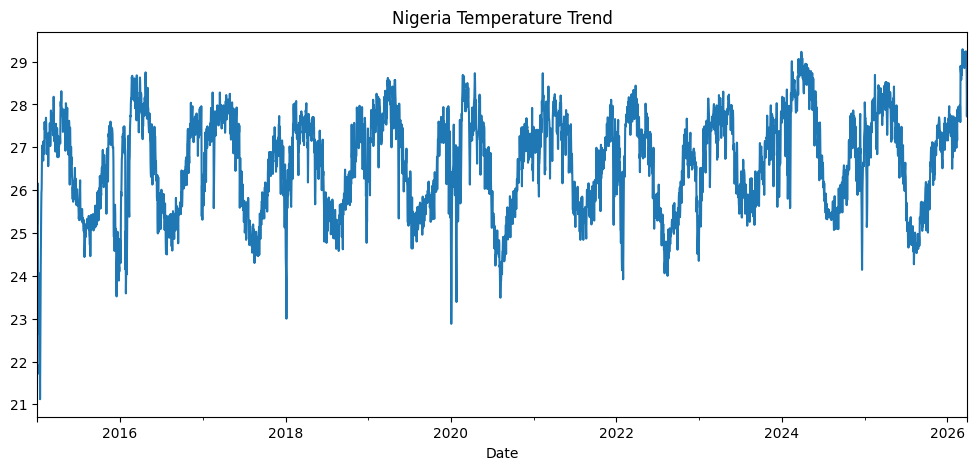

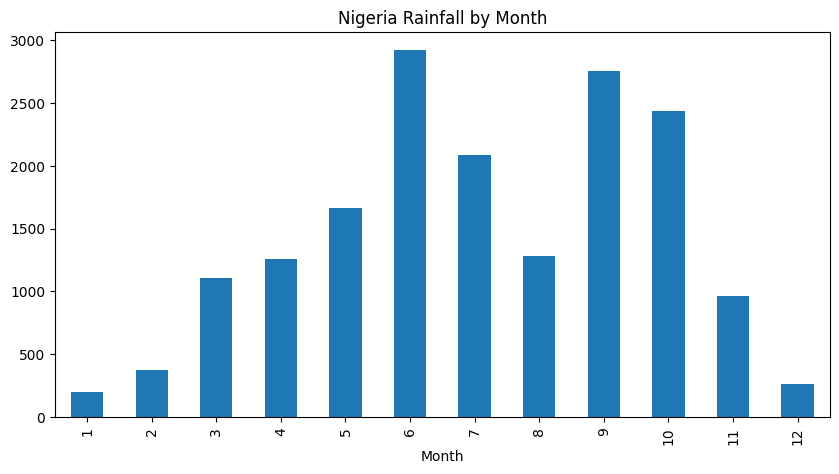

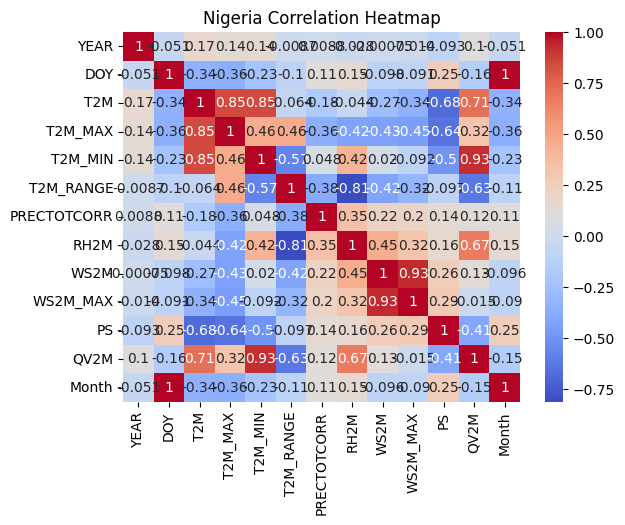

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/nigeria.csv')

df["Country"] = "Nigeria"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.replace(-999, np.nan, inplace=True)

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.describe())

print(df.isna().sum())

df.ffill(inplace=True)

monthly_temp = df.groupby("Date")["T2M"].mean()

plt.figure(figsize=(12,5))
monthly_temp.plot()
plt.title("Nigeria Temperature Trend")
plt.show()

monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")
plt.title("Nigeria Rainfall by Month")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Nigeria Correlation Heatmap")
plt.show()
